# 02 Forecasting Frekuensi, Severity, dan Total Klaim

Tugas kompetisi: memprediksi frekuensi, severity, dan total klaim per bulan untuk Agustus sampai
Desember 2025. Skor dihitung dengan MAPE untuk masing-masing target, lalu dirata-rata.

Data hanya 19 bulan, jadi metode dipilih dengan **rolling-origin backtest**: berpura-pura berada di
akhir setiap bulan dari Juni 2024 sampai Februari 2025, memprediksi 5 bulan berikutnya hanya dari
data sebelumnya, lalu membandingkannya dengan data asli. Horizon 5 bulan sama dengan tugas kompetisi.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import klaim

pd.set_option("display.float_format", "{:,.1f}".format)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False})
JUTA = 1e6

In [2]:
k = klaim.muat_klaim()
g = klaim.per_bulan(k)
print(f"{len(g)} bulan: {g.index.min()} s.d. {g.index.max()}")

19 bulan: 2024-01 s.d. 2025-07


## 1. Membandingkan sepuluh metode

Dari yang paling sederhana (rata-rata) sampai yang menangkap tren (tren linear, Holt). Angka di
tabel adalah MAPE rata-rata dari 9 titik backtest, dalam persen. Makin kecil makin baik.

In [3]:
hasil = klaim.backtest(g, klaim.METODE)
hasil

target,Claim_Frequency,Claim_Severity,Total_Claim,Skor gabungan
metode,,,,
Rata-rata 6 bulan,8.1,10.9,12.4,10.5
Median 6 bulan,8.2,11.9,12.1,10.7
Median semua bulan,9.0,12.3,13.1,11.5
Rata-rata 12 bulan,8.9,12.1,14.4,11.8
Rata-rata semua bulan,9.0,12.0,14.3,11.8
Rata-rata 3 bulan,9.1,13.4,13.2,11.9
Simple exponential smoothing,9.0,14.7,14.4,12.7
Holt dengan tren teredam,8.7,14.0,17.8,13.5
Bulan terakhir,11.6,17.4,19.1,16.1


Metode yang menangkap tren (tren linear, Holt) tidak lebih baik daripada rata-rata biasa. Dengan
jumlah nasabah yang tetap dan deret yang pendek, "tren" yang ditangkap lebih banyak berupa kebetulan.

Rata-rata 6 bulan terakhir memberi skor gabungan terbaik. Namun selisihnya dengan rata-rata lain hanya
sekitar satu poin, dan 9 titik backtest saling tumpang tindih, jadi selisih sekecil itu tidak boleh
dianggap pasti.

## 2. Faktor koreksi untuk MAPE

MAPE tidak simetris. Kalau aktualnya 100, menebak 150 memberi error 50%, sedangkan menebak 50 juga
50%. Namun kalau aktualnya 50 dan kita menebak 100, errornya 100%. Prediksi yang terlalu tinggi
dihukum lebih berat, sehingga prediksi yang sedikit diturunkan sering memberi MAPE lebih kecil.

Faktor pengali diuji dengan backtest yang sama.

In [4]:
faktor = [0.90, 0.93, 0.95, 0.97, 1.00]
tabel = {f: klaim.backtest(g, {"x": klaim.dikali(klaim.rata_rata(6), f)}).iloc[0] for f in faktor}
tabel = pd.DataFrame(tabel).T
tabel.index = [f"{f:.2f}" for f in faktor]
tabel.index.name = "faktor"
tabel

target,Claim_Frequency,Claim_Severity,Total_Claim,Skor gabungan
faktor,,,,
0.90,9.3,12.5,12.9,11.6
0.93,8.1,11.0,11.9,10.3
0.95,7.6,10.5,11.7,9.9
0.97,7.4,10.5,11.8,9.9
1.00,8.1,10.9,12.4,10.5


Faktor 0,95 memperbaiki ketiga target sekaligus, dan skor gabungan turun sekitar setengah poin.
Karena perbaikannya muncul di ketiga target, bukan hanya satu, faktor ini dipakai.

Tetap ada risiko: faktor ini dipilih dari data yang sama dengan backtest. Nilainya sengaja tidak
disetel lebih halus dari kelipatan 0,05 supaya tidak terlalu menyesuaikan diri dengan 9 titik itu.

## 3. Metode final

**Rata-rata 6 bulan terakhir, dikali 0,95**, untuk ketiga target secara terpisah.

In [5]:
final = klaim.dikali(klaim.rata_rata(6), 0.95)
akhir = klaim.backtest(g, {"Rata-rata 6 bulan x 0,95": final,
                           "Rata-rata 6 bulan": klaim.rata_rata(6),
                           "Rata-rata semua bulan": klaim.rata_rata()})
akhir

target,Claim_Frequency,Claim_Severity,Total_Claim,Skor gabungan
metode,,,,
"Rata-rata 6 bulan x 0,95",7.6,10.5,11.7,9.9
Rata-rata 6 bulan,8.1,10.9,12.4,10.5
Rata-rata semua bulan,9.0,12.0,14.3,11.8


## 4. Prediksi Agustus sampai Desember 2025

In [6]:
sub = klaim.buat_submission(g, final)
out = Path.cwd().parent / "submission" / "submission.csv"
sub.to_csv(out, index=False)
print("Disimpan ke", out)
sub

Disimpan ke D:\KULIAH BINUS\PORTOFOLIO MAGANG\MCF ITB\submission\submission.csv


,id,value
0,2025_08_Claim_Frequency,225.0
1,2025_08_Claim_Severity,"54,531,199.0"
2,2025_08_Total_Claim,"12,923,668,797.1"
3,2025_09_Claim_Frequency,225.0
4,2025_09_Claim_Severity,"54,531,199.0"
5,2025_09_Total_Claim,"12,923,668,797.1"
6,2025_10_Claim_Frequency,225.0
7,2025_10_Claim_Severity,"54,531,199.0"
8,2025_10_Total_Claim,"12,923,668,797.1"
9,2025_11_Claim_Frequency,225.0


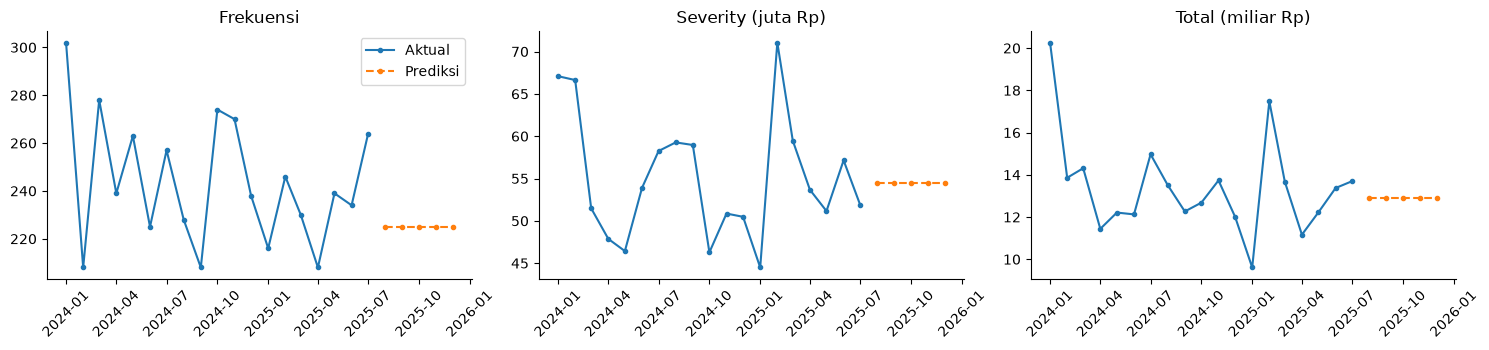

In [7]:
pred = sub.assign(bulan=sub["id"].str[:7], target=sub["id"].str[8:]).pivot(index="bulan", columns="target", values="value")
bulan_pred = pd.PeriodIndex(pred.index.str.replace("_", "-"), freq="M")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (kolom, judul, skala) in zip(axes, [("Claim_Frequency", "Frekuensi", 1),
                                           ("Claim_Severity", "Severity (juta Rp)", JUTA),
                                           ("Total_Claim", "Total (miliar Rp)", 1e9)]):
    ax.plot(g.index.to_timestamp(), g[kolom] / skala, marker="o", ms=3, label="Aktual")
    ax.plot(bulan_pred.to_timestamp(), pred[kolom].values / skala, marker="o", ms=3, ls="--", label="Prediksi")
    ax.set_title(judul)
    ax.tick_params(axis="x", rotation=45)
axes[0].legend()
plt.tight_layout()
plt.show()

Prediksinya berupa garis datar. Ini disengaja: backtest menunjukkan bahwa mencoba menebak naik
turun bulanan justru memperbesar error. Untuk kebutuhan bisnis, angka ini dibaca sebagai perkiraan
beban klaim rata-rata per bulan, dengan catatan bahwa satu atau dua klaim raksasa bisa menggeser
total bulan tertentu sampai sekitar 20%.

## Keterbatasan

- Hanya 19 bulan data, sehingga pola musiman tahunan tidak bisa diuji (hanya ada satu Agustus sampai
  Desember sebelumnya).
- Severity, frekuensi, dan total diprediksi terpisah, jadi hasil prediksi severity dikali frekuensi
  tidak persis sama dengan prediksi total. Ini sesuai format penilaian, yang menilai ketiganya terpisah.
- Bulan klaim diasumsikan dihitung dari tanggal pasien masuk RS. Kalau panitia memakai tanggal lain,
  skor resmi bisa berbeda dari hasil backtest.